In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# set the themes
sns.set_theme(style="whitegrid")
%matplotlib inline

## Setup

Import libraries and configure plot styling.

# Carbon Emissions and Economic Analysis

This notebook explores the relationship between CO2 emissions and economic development by merging two datasets:

1. **CO2 Emissions** (Our World in Data, 1750-2024) — historical emissions by country
2. **GDP** (World Bank, 1960-2024) — economic output in current USD

We clean and merge both sources, compute per-capita metrics, and visualize trends for selected countries.

## CO2 Emissions Data

We load the Our World in Data CO2 dataset (79 columns) and reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2`. Rows without an `iso_code` are dropped — these are aggregate entities like "Africa" or "OECD" rather than individual countries. We also filter to post-1960 to align with the GDP data coverage.

In [40]:
df = pd.read_csv('data/co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
df = df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
df = df[df['iso_code'].notna() & (df['iso_code'].str.strip() != '')]
df = df[df['year'] > 1960]

df



,country,year,iso_code,population,co2
211,Afghanistan,1961,AFG,9214082.0,0.491
212,Afghanistan,1962,AFG,9404410.0,0.689
213,Afghanistan,1963,AFG,9604491.0,0.707
214,Afghanistan,1964,AFG,9814317.0,0.839
215,Afghanistan,1965,AFG,10036003.0,1.007
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## GDP Data

The World Bank GDP data arrives in **wide format** (one column per year), so we melt it into long format to match the CO2 dataset's structure. We rename `Country Code` to `iso_code` for a clean merge key and drop rows with missing GDP values.

In [41]:
# load GDP data
gdp_df = pd.read_csv('data/gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_long = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long['gdp'] = pd.to_numeric(gdp_long['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_long = gdp_long.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_long = gdp_long[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_long = gdp_long.dropna(subset=['gdp'])

print(f"GDP data shape: {gdp_long.shape}")

gdp_long

GDP data shape: (14561, 3)


,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Merging the Datasets

We left-join GDP onto the CO2 dataframe using `iso_code` and `year`. A left join preserves all CO2 records and attaches GDP where available — countries or years without GDP data simply get NaN.

### Missing Data Heatmap

The heatmap below gives a quick visual diagnostic of data completeness. Each column is a variable, each row a record — bright spots indicate missing values. This is useful because it reveals **systematic gaps**: for instance, whether missingness is random or concentrated in certain time periods or countries. In our case, `co2` values are occasionally missing for earlier years in smaller nations, which is expected.

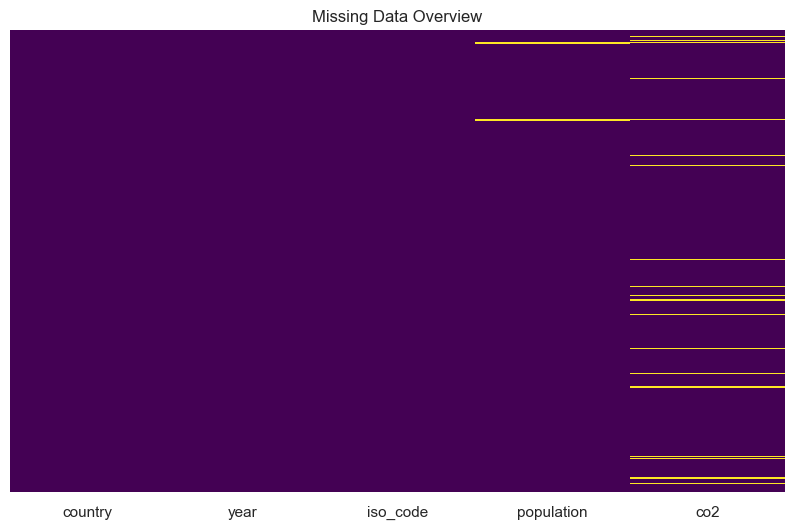

In [42]:
# merge the datasets on iso_code and year, append gdp to the right
merged_df = df.merge(
    gdp_long,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# show the dataframe as heatmap to see where we have missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Overview")
plt.show()


## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people. Dividing by population gives us **per-capita** values that allow fairer comparisons: how much does an average person emit, and how wealthy is an average person? We use `np.divide` with a `where` guard to safely handle zero or missing population entries.

In [43]:
# extract as numpy arrays
pop_arr = merged_df['population'].values
co2_arr = merged_df['co2'].values
gdp_arr = merged_df['gdp']

# vectorized division, check for NaN or invalid values and only calculate the correct values
merged_df['co2_per_capita'] = np.divide(co2_arr, pop_arr, out = np.zeros_like(co2_arr), where = pop_arr > 0)
merged_df['gdp_per_capita'] = np.divide(gdp_arr, pop_arr, out = np.zeros_like(gdp_arr), where = pop_arr > 0)



## Country-Level Analysis: GDP vs CO2 Over Time

The dual-axis line plot below overlays GDP per capita and CO2 per capita for a selected country. Using two y-axes lets us compare trends that have very different scales on a single timeline.

**Why this plot matters:** It directly tests the core question of this analysis - does economic growth go hand-in-hand with rising emissions, or can the two decouple? A country where GDP keeps climbing while CO2 flattens or drops is evidence of **decoupling**, often driven by shifts toward services, renewables, or efficiency gains. Conversely, parallel upward trends suggest the economy is still carbon-intensive.

In [59]:
# random choice of countries to be compares
country = 'Afghanistan'
my_selection = [country]

# create a dataframe just for those countries
df_selected = merged_df[merged_df['country'].isin(my_selection)]

df_selected


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita
0,Afghanistan,1961,AFG,9214082.0,0.491,NaN,5.328800e-08,NaN
1,Afghanistan,1962,AFG,9404410.0,0.689,NaN,7.326350e-08,NaN
2,Afghanistan,1963,AFG,9604491.0,0.707,NaN,7.361140e-08,NaN
3,Afghanistan,1964,AFG,9814317.0,0.839,NaN,8.548735e-08,NaN
4,Afghanistan,1965,AFG,10036003.0,1.007,NaN,1.003388e-07,NaN
...,...,...,...,...,...,...,...,...
59,Afghanistan,2020,AFG,39068977.0,11.119,1.995593e+10,2.845992e-07,510.787090
60,Afghanistan,2021,AFG,40000410.0,9.869,1.426000e+10,2.467225e-07,356.496232
61,Afghanistan,2022,AFG,40578847.0,10.170,1.449724e+10,2.506232e-07,357.261109
62,Afghanistan,2023,AFG,41454762.0,10.516,1.715223e+10,2.536741e-07,413.757885


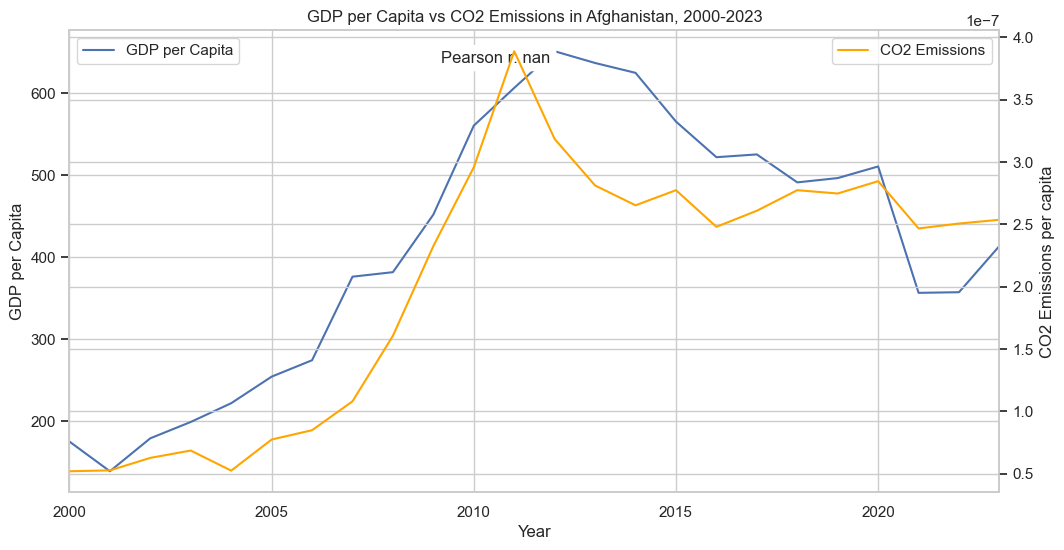

In [ ]:
# create a figure and axes

# first ax is for gdp per capita
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_selected['year'], df_selected['gdp_per_capita'], label='GDP per Capita')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP per Capita')
ax1.legend(loc='upper left')

# second ax is for co2 per capita, just a twin of the first ax
ax2 = ax1.twinx()
ax2.plot(df_selected['year'], df_selected['co2_per_capita'], label='CO2 Emissions', color='orange')
ax2.set_ylabel('CO2 Emissions per capita')
ax2.legend(loc='upper right')

# short numpy check for the correlation
try:
    correlation = np.corrcoef(df_selected['gdp_per_capita'].dropna(), df_selected['co2_per_capita'].dropna())[0, 1]
except ValueError:
    correlation = np.nan

# annotate
ax1.annotate(f'Pearson r: {correlation:.2f}', xy=(0.4, 0.93), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

# set the x axis to the min and max of the valid years, as some countries have missing data
valid_years = df_selected.dropna(subset=['gdp_per_capita', 'co2_per_capita'])['year']

if not valid_years.empty:
    min_year = valid_years.min()
    max_year = valid_years.max()
    ax1.set_xlim(min_year, max_year)

# show the plot
plt.title(f'GDP per Capita vs CO2 Emissions in {country}, {min_year}-{max_year}')
plt.show()